Missing values per column:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


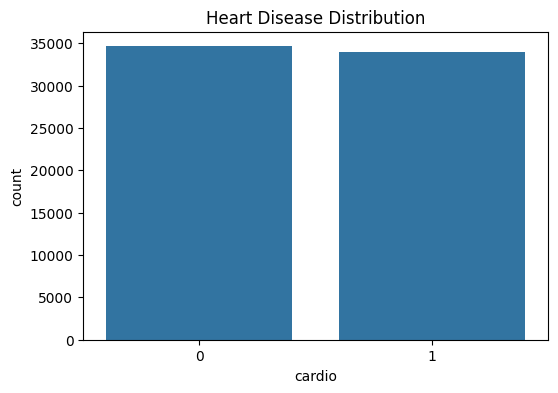

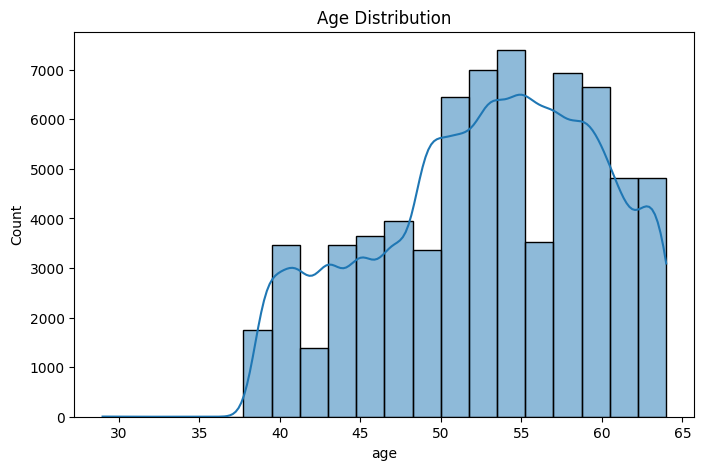

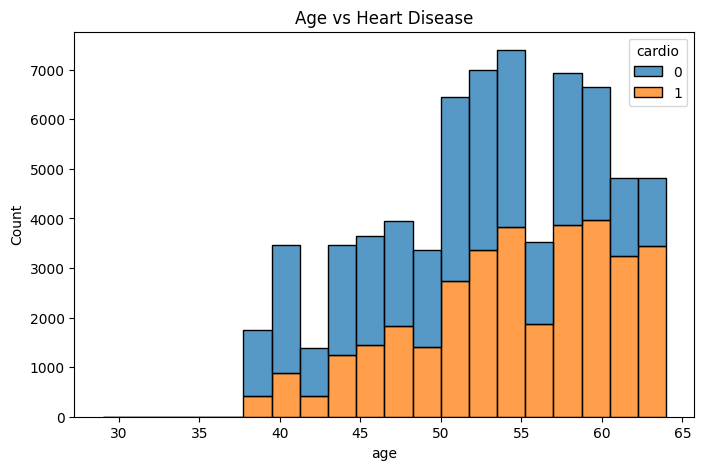

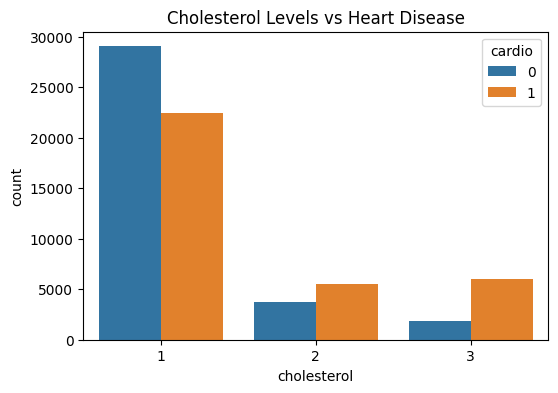

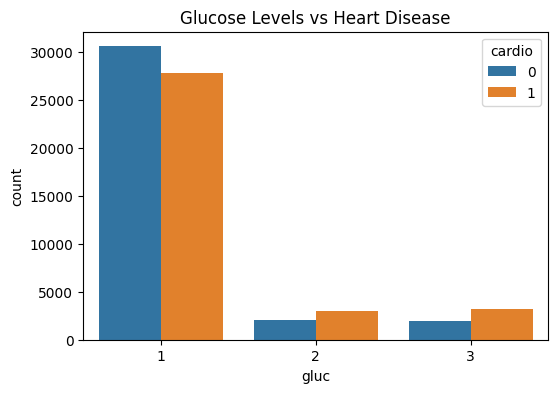

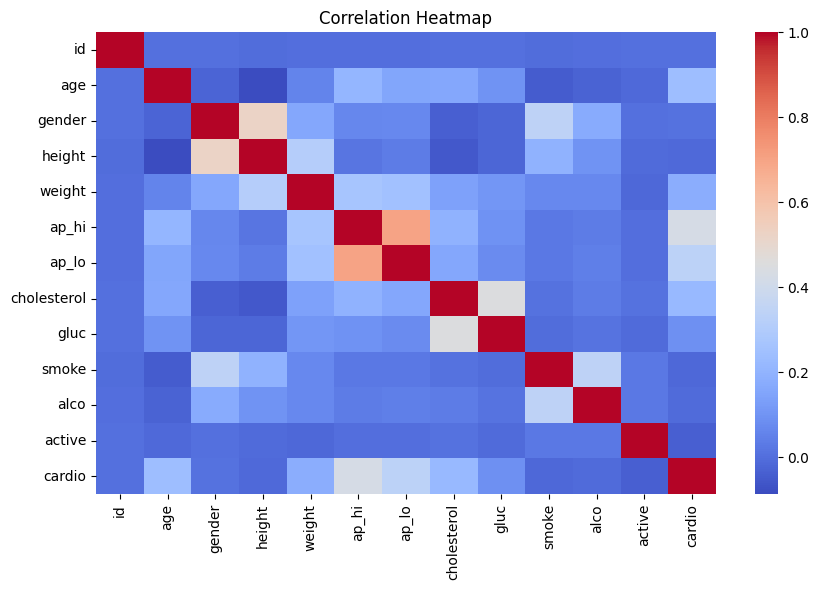


Logistic Regression Accuracy: 73.01%
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6946
           1       0.75      0.67      0.71      6775

    accuracy                           0.73     13721
   macro avg       0.73      0.73      0.73     13721
weighted avg       0.73      0.73      0.73     13721


KNN Accuracy: 70.35%
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6946
           1       0.71      0.69      0.70      6775

    accuracy                           0.70     13721
   macro avg       0.70      0.70      0.70     13721
weighted avg       0.70      0.70      0.70     13721


Decision Tree Accuracy: 73.31%
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6946
           1       0.76      0.68      0.72      6775

    accuracy                           0.73     13721
   macro avg       0.74      0.73   

In [ ]:
# ==========================================
# Cardiovascular Disease Prediction Project
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# ------------------------------------------
# 2. Load Dataset
# ------------------------------------------
df = pd.read_csv("cardio_train.csv", sep=';')

# ------------------------------------------
# 3. Basic Preprocessing
# ------------------------------------------

# Convert age from days to years
df['age'] = (df['age'] / 365).astype(int)

# Remove unrealistic height and weight
df = df[(df['height'] >= 140) & (df['height'] <= 210)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# Remove unrealistic blood pressure readings
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# ------------------------------------------
# 4. Exploratory Data Analysis (EDA)
# ------------------------------------------

# Heart disease distribution
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Age vs Heart Disease
plt.figure(figsize=(8,5))
sns.histplot(x='age', hue='cardio', data=df, bins=20, multiple='stack')
plt.title("Age vs Heart Disease")
plt.show()

# Cholesterol vs Heart Disease
plt.figure(figsize=(6,4))
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

# Glucose vs Heart Disease
plt.figure(figsize=(6,4))
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title("Glucose Levels vs Heart Disease")
plt.show()

# ------------------------------------------
# 5. Correlation Heatmap
# ------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# 6. Model Training & Evaluation
# ------------------------------------------

# Features & Target
X = df.drop(['id', 'cardio'], axis=1)
y = df['cardio']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models to Compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "SVM": SVC(kernel='rbf', C=2)
}

results = {}

# Train and Evaluate Each Model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds))

# ------------------------------------------
# 7. Best Model Selection
# ------------------------------------------
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy*100:.2f}%")

# ------------------------------------------
# 8. Save Best Model
# ------------------------------------------
best_model = models[best_model_name]
joblib.dump(best_model, "best_heart_disease_model.pkl")
print("Model saved as best_heart_disease_model.pkl")

# Save Scaler as well
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved as scaler.pkl")
